# Attacks and triggers

Every attack in this project is the same 4-field record, not a class hierarchy:
a name, a function that stamps the trigger onto one image, a label policy, and a
target label. `psbd/attacks/__init__.py` is a dispatcher over those records, so a
caller writes `build_attack("wanet", ...)` and never learns which file WaNet lives
in.

This notebook builds every registered attack, looks at what each trigger does to
one image, measures how visible each one is, and then separates the trigger from
the label policy, which is where the 2 easiest mistakes in backdoor evaluation
live.

Everything here is CPU work. A trigger is a pixel-space function of an image, so
none of it needs a model, a checkpoint, or a GPU.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in psbd resolves the same
# way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from dataclasses import asdict

import matplotlib.pyplot as plt
import pandas as pd
import torch

from psbd.attacks import ATTACK_NAMES, build_attack, default_config
from psbd.config import DATASET_REGISTRY
from psbd.eval_loaders import load_test_base
from psbd.poisoning import (
    AttackSuccessSet,
    attack_success_label,
    is_eval_poisonable,
    is_poisonable,
    poisoned_label,
)
from psbd.stealth import build_clean_triggered_pairs, compute_stealth_metrics

DEVICE = torch.device("cpu")
DATASET = "cifar100"
TARGET_LABEL = 0
print("torch", torch.__version__, "device", DEVICE)

torch 2.6.0+cu124 device cpu


## The registry

`ATTACK_NAMES` carries 12 entries for 10 attack modules. 2 of the entries are not
new attacks. `badnet` is an alias of `badnet_a2o`, both built by
`_badnet_all_to_one`, and `generated` is an adapter for pregenerated poisoned
images that has no default config at all, because its `poisoned_dir` has no
sensible default. Both are excluded from the tour below, leaving exactly 10
buildable triggers.

In [2]:
SKIP = ("badnet", "generated")
TRIGGER_NAMES = [name for name in ATTACK_NAMES if name not in SKIP]

spec = DATASET_REGISTRY[DATASET]
attacks = {
    name: build_attack(name, default_config(name), spec.image_size, TARGET_LABEL)
    for name in TRIGGER_NAMES
}

registry = pd.DataFrame(
    [
        {
            "attack": name,
            "label_mode": attacks[name].label_mode,
            "record_name": attacks[name].name,
            "config": ", ".join(
                f"{key}={value}"
                for key, value in asdict(default_config(name)).items()
                if key != "label_mode"
            ),
        }
        for name in TRIGGER_NAMES
    ]
).set_index("attack")

print(f"registry entries {len(ATTACK_NAMES)}, buildable triggers {len(TRIGGER_NAMES)}")
registry

registry entries 12, buildable triggers 10


,label_mode,record_name,config
attack,,,
badnet_a2o,all_to_one,badnet,patch_size=3
badnet_a2a,all_to_all,badnet,patch_size=3
blend,all_to_one,blend,"alpha=0.2, pattern_seed=0"
sig,clean_label,sig,"amplitude=0.1, frequency=6.0"
wanet,all_to_one,wanet,"control_grid_size=4, strength=0.5, field_seed=0"
lf,all_to_one,lf,"strength=0.1, cutoff=4, pattern_seed=0"
lc,clean_label,lc,patch_size=3
bpp,all_to_one,bpp,"bit_depth=3, dither=False"
adaptive_blend,all_to_one,adaptive_blend,"alpha=0.2, cover_rate=0.01, pattern_seed=0"


In [3]:
try:
    default_config("generated")
except ValueError as error:
    print("generated:", error)

generated: generated has no default config, build its config directly


## What each trigger is

**Patch, opaque, fixed location.** `badnet_a2o`, `badnet_a2a`, `lc` and `tact` all
stamp the same 3 by 3 checkerboard from `psbd/attacks/_patterns.py`, which
overwrites 9 of the 1024 pixels of a 32 by 32 image, 0.88 percent of the area.
What separates them is placement and label policy, not appearance. BadNet puts it
in the bottom-right corner. Label-Consistent repeats it in all 4 corners, so it
overwrites 36 pixels. TaCT uses BadNet's corner but restricts poisoning to
`source_classes` and adds cover samples at `cover_rate`. `patch_size` is the side
of the square in native pixels, 3 to match BackdoorBench at 32 by 32.

**Blended, full image, low alpha.** `blend` and `adaptive_blend` compute
`(1 - alpha) * image + alpha * pattern` over every pixel, with `alpha` the blend
ratio (0.2, the upper end of the 0.1 to 0.2 range in the literature) and
`pattern_seed` fixing the seeded random pattern that stands in for the original
paper's Hello Kitty image. Adaptive-Blend's only registered difference is
`cover_rate`, the fraction of images that get the trigger and keep their true
label, which flattens the latent separation defenses look for. Its trigger is
byte-identical to Blend's, asserted below.

**Additive signal.** `sig` adds one value per image column,
`amplitude * sin(2 * pi * frequency * column / width)`, so the perturbation is a
vertical stripe pattern of amplitude 0.1 repeated `frequency` times (6) across the
width, clamped back into the 0-to-1 range. `lf` adds a fixed noise pattern that
has been low-pass filtered in the Fourier domain, keeping only frequencies within
`cutoff` (4) of the spectrum center, scaled by `strength` (0.1). Both spread their
energy over the whole image rather than concentrating it in a corner.

**Warping.** `wanet` moves pixels instead of changing their values. A
`control_grid_size` by `control_grid_size` grid (4 by 4) of random offsets is
upsampled bicubically to full resolution, which is what makes the field smooth,
and `strength` (0.5) scales how far pixels travel. Because it resamples, its
difference image traces edges rather than showing a pattern of its own, and it is
the only attack here whose difference depends on the image content.

**Quantization.** `bpp` reduces color depth to `bit_depth` bits per channel (3,
giving 8 levels). `dither` is off by default because Floyd-Steinberg error
diffusion is a sequential per-pixel loop that would run on every image of every
epoch. Off means visible banding, which is the loud variant of the attack, and the
imperceptible one is behind that flag.

**Pregenerated.** `generated` reads index-named poisoned PNGs from disk, which is
how SSBA, TrojanNN and ISSBA are served, since their triggers come from a trained
generator or a model-specific optimization rather than a formula.

In [4]:
test_base, _ = load_test_base(DATASET, "raw_data")
EXAMPLE_INDEX = 7
example_image, example_label = test_base[EXAMPLE_INDEX]

# The 3 attacks that share the checkerboard corner and the 2 that share the blend
# pattern produce identical pixels, so any difference in their measured detection
# comes from the label policy or the cover samples, never from the trigger.
badnet_image = attacks["badnet_a2o"].apply_trigger(example_image, EXAMPLE_INDEX)
assert torch.equal(
    badnet_image, attacks["badnet_a2a"].apply_trigger(example_image, EXAMPLE_INDEX)
)
assert torch.equal(
    badnet_image, attacks["tact"].apply_trigger(example_image, EXAMPLE_INDEX)
)
assert torch.equal(
    attacks["blend"].apply_trigger(example_image, EXAMPLE_INDEX),
    attacks["adaptive_blend"].apply_trigger(example_image, EXAMPLE_INDEX),
)
print("badnet_a2o, badnet_a2a and tact stamp identical pixels")
print("blend and adaptive_blend stamp identical pixels")
print(f"example image {tuple(example_image.shape)}, class {example_label}")

/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


badnet_a2o, badnet_a2a and tact stamp identical pixels
blend and adaptive_blend stamp identical pixels
example image (3, 32, 32), class 14


## The triggers on one image

The third column is the absolute difference, rescaled by its own maximum so a
0.1-amplitude perturbation and an opaque patch are both visible. That rescaling
throws away magnitude, so each row's title carries the real maximum and the
fraction of pixels the trigger touches. Magnitude comes back quantitatively in the
stealth table below.

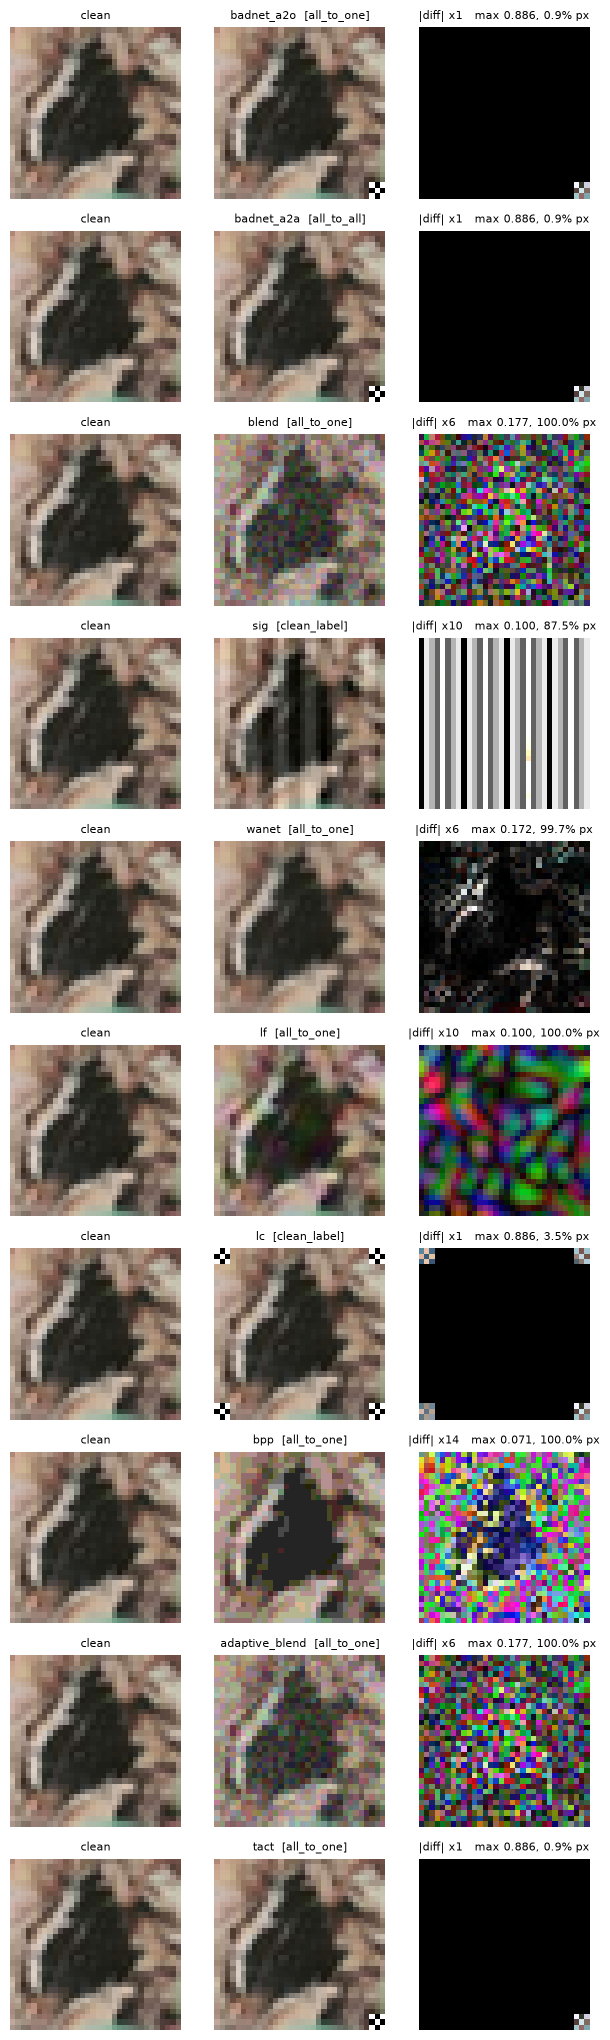

In [5]:
def trigger_row_statistics(attack, image, index):
    """Max absolute change and touched-pixel fraction for one trigger on one image."""
    triggered = attack.apply_trigger(image, index)
    difference = (triggered - image).abs()
    statistics = {
        "triggered": triggered,
        "difference": difference,
        "max_abs": float(difference.max()),
        "touched_fraction": float((difference > 1e-6).float().mean()),
    }
    return statistics


def plot_trigger_grid(attacks, image, index):
    figure, axes = plt.subplots(len(attacks), 3, figsize=(6.4, 2.05 * len(attacks)))
    for axis_row, (name, attack) in zip(axes, attacks.items()):
        row = trigger_row_statistics(attack, image, index)
        amplified = row["difference"] / max(row["max_abs"], 1e-8)

        for axis, picture, title in zip(
            axis_row,
            [image, row["triggered"], amplified],
            [
                "clean",
                f"{name}  [{attack.label_mode}]",
                f"|diff| x{1 / max(row['max_abs'], 1e-8):.0f}   "
                f"max {row['max_abs']:.3f}, {100 * row['touched_fraction']:.1f}% px",
            ],
        ):
            axis.imshow(picture.permute(1, 2, 0).numpy(), interpolation="nearest")
            axis.set_title(title, fontsize=8)
            axis.axis("off")
    figure.tight_layout()
    return figure


plot_trigger_grid(attacks, example_image, EXAMPLE_INDEX)
plt.show()

Read the third column for the shape of the perturbation. The patch attacks touch
under 4 percent of the pixels but change them completely. The blend, signal and
quantization attacks touch every pixel by a small amount. WaNet is the odd one:
its difference is an outline of the image itself, because a warp only changes a
pixel where its neighbours differ, which is why a flat region of a warped image is
bit-identical to the clean one.

### Bpp with dithering on

`BppConfig.dither` defaults to `False` for a runtime reason, not a fidelity one:
Floyd-Steinberg error diffusion is a sequential loop over every pixel, and the
poisoned training set is rebuilt every epoch. The paper's trigger is the dithered
one, and the difference is what the banding looks like.

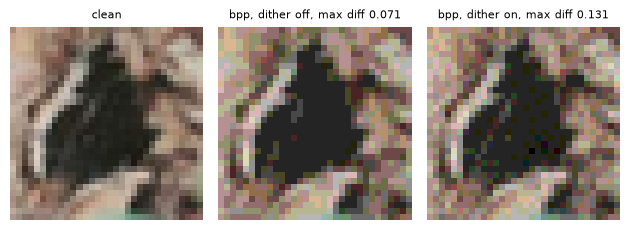

In [6]:
from psbd.attacks.bpp import BppConfig

dithered_attack = build_attack(
    "bpp", BppConfig(dither=True), spec.image_size, TARGET_LABEL
)
plain = attacks["bpp"].apply_trigger(example_image, EXAMPLE_INDEX)
dithered = dithered_attack.apply_trigger(example_image, EXAMPLE_INDEX)

figure, axes = plt.subplots(1, 3, figsize=(6.4, 2.3))
for axis, picture, title in zip(
    axes,
    [example_image, plain, dithered],
    [
        "clean",
        f"bpp, dither off, max diff {float((plain - example_image).abs().max()):.3f}",
        f"bpp, dither on, max diff {float((dithered - example_image).abs().max()):.3f}",
    ],
):
    axis.imshow(picture.permute(1, 2, 0).numpy(), interpolation="nearest")
    axis.set_title(title, fontsize=8)
    axis.axis("off")
figure.tight_layout()
plt.show()

## Stealth

Stealth asks the opposite question from attack success rate: not how well the
trigger fools the model, but how hard it is for a person to notice. `psbd/stealth.py`
measures it on index-aligned pairs, each clean test image against its own
triggered self, in the 0-to-1 pixel range where the triggers are defined and in
float32 regardless of the bfloat16 used for model evaluation, because PSNR is an
MSE ratio in decibels and is precision-sensitive.

| metric | reading | direction |
|---|---|---|
| PSNR | `10 * log10(1 / mean_squared_error)`, a pure pixel-error ratio in decibels | higher is stealthier |
| SSIM | local luminance, contrast and structure agreement, 1 when identical | higher is stealthier |
| LPIPS | distance between AlexNet feature maps of the 2 images, a learned perceptual metric | lower is stealthier |

LPIPS does run here. The `lpips` package ships its linear-head weights inside the
installed distribution and the AlexNet backbone is already in the local torch hub
cache, so no download and no GPU is needed. It is the slowest of the 3 and is why
`psbd.stealth` memoizes on `(dataset, attack)`.

Sampling note: the stealth pairs are a seeded random subset of the test set rather
than the whole of it, so these numbers are estimates over 512 images. A larger
`STEALTH_SAMPLES` moves them by less than the reported standard deviations.

In [7]:
STEALTH_SAMPLES = 512


def stealth_table(dataset_name):
    """Per-attack PSNR, SSIM and LPIPS on one dataset, CPU only."""
    dataset_spec = DATASET_REGISTRY[dataset_name]
    rows = []
    for name in TRIGGER_NAMES:
        attack = build_attack(
            name, default_config(name), dataset_spec.image_size, TARGET_LABEL
        )
        clean, triggered = build_clean_triggered_pairs(
            dataset_name, attack, "raw_data", max_samples=STEALTH_SAMPLES, seed=0
        )
        metrics = compute_stealth_metrics(
            clean,
            triggered,
            DEVICE,
            batch_size=64,
            max_samples=STEALTH_SAMPLES,
            seed=0,
        )
        rows.append(
            {
                "attack": name,
                "label_mode": attack.label_mode,
                "psnr_db": metrics["psnr_mean"],
                "psnr_std": metrics["psnr_std"],
                "ssim": metrics["ssim_mean"],
                "ssim_std": metrics["ssim_std"],
                "lpips": metrics["lpips_mean"],
                "lpips_std": metrics["lpips_std"],
                "n_pairs": metrics["n_pairs"],
            }
        )
    return pd.DataFrame(rows).set_index("attack")


cifar_stealth = stealth_table(DATASET)
cifar_stealth.round(4)

/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(
/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


Loading model from: /lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth


,label_mode,psnr_db,psnr_std,ssim,ssim_std,lpips,lpips_std,n_pairs
attack,,,,,,,,
badnet_a2o,all_to_one,25.3982,0.8908,0.9727,0.0066,0.0006,0.0005,512
badnet_a2a,all_to_all,25.3982,0.8908,0.9727,0.0066,0.0006,0.0005,512
blend,all_to_one,22.1889,1.0037,0.6881,0.1055,0.0248,0.0200,512
sig,clean_label,23.2568,0.3688,0.6873,0.1144,0.0520,0.0388,512
wanet,all_to_one,32.3182,2.8070,0.9743,0.0086,0.0046,0.0023,512
lf,all_to_one,30.9324,0.3230,0.9314,0.0388,0.0112,0.0107,512
lc,clean_label,19.2889,0.7274,0.8882,0.0194,0.0029,0.0024,512
bpp,all_to_one,27.9484,0.8501,0.8681,0.0619,0.0075,0.0089,512
adaptive_blend,all_to_one,22.1889,1.0037,0.6881,0.1055,0.0248,0.0200,512


The 3 metrics disagree, which is the point of reporting all 3. `lc` has the worst
PSNR in the table because it overwrites 36 pixels outright, and at the same time
the second lowest LPIPS, 8.6 times lower than `blend`'s, because AlexNet features
barely register 4 small corner blocks while they do register a pattern laid over
the whole image. A claim that one attack is stealthier than another has to name
the metric it was made under.

distinct triggers 7 of 10 rows
spearman correlation, psnr against lpips: -0.071
perfect agreement between the 2 metrics would be -1.000


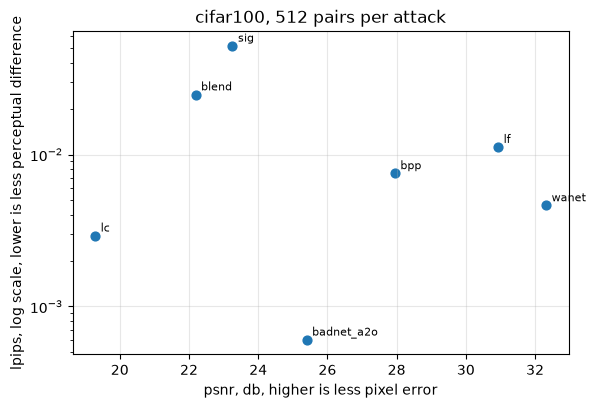

In [8]:
# Deduplicated, since the 3 pixel-identical pairs would otherwise weight their
# shared trigger 3 times in a rank correlation over 10 rows.
distinct = cifar_stealth.drop_duplicates(subset=["psnr_db", "ssim", "lpips"])
rank_agreement = distinct["psnr_db"].corr(distinct["lpips"], method="spearman")


def plot_stealth_disagreement(table):
    figure, axis = plt.subplots(figsize=(6.4, 4.2))
    axis.scatter(table["psnr_db"], table["lpips"], s=40)
    for name, row in table.iterrows():
        axis.annotate(
            name,
            (row["psnr_db"], row["lpips"]),
            fontsize=8,
            xytext=(4, 3),
            textcoords="offset points",
        )
    axis.set_yscale("log")
    axis.set_xlabel("psnr, db, higher is less pixel error")
    axis.set_ylabel("lpips, log scale, lower is less perceptual difference")
    axis.set_title(f"{DATASET}, {STEALTH_SAMPLES} pairs per attack")
    axis.grid(alpha=0.3)
    return figure


print(f"distinct triggers {len(distinct)} of {len(cifar_stealth)} rows")
print(f"spearman correlation, psnr against lpips: {rank_agreement:+.3f}")
print("perfect agreement between the 2 metrics would be -1.000")
plot_stealth_disagreement(distinct)
plt.show()

### The same triggers at 64 by 64

Trigger configs are written in native pixels, so resolution alone changes stealth
with nothing in the config changing. The 3 by 3 patch covers 0.88 percent of a 32
by 32 image and 0.22 percent of a 64 by 64 one, so the patch attacks should gain
and the full-image attacks should not. Read the `psnr_gain` column against that
prediction, and read `lpips_tiny` against `lpips_cifar100` separately, because the
2 metrics move in different directions here as well.

In [9]:
tiny_stealth = stealth_table("tiny")

comparison = pd.DataFrame(
    {
        "psnr_cifar100": cifar_stealth["psnr_db"],
        "psnr_tiny": tiny_stealth["psnr_db"],
        "psnr_gain": tiny_stealth["psnr_db"] - cifar_stealth["psnr_db"],
        "lpips_cifar100": cifar_stealth["lpips"],
        "lpips_tiny": tiny_stealth["lpips"],
    }
)
comparison.round(4)

/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


,psnr_cifar100,psnr_tiny,psnr_gain,lpips_cifar100,lpips_tiny
attack,,,,,
badnet_a2o,25.3982,31.2042,5.8060,0.0006,0.0003
badnet_a2a,25.3982,31.2042,5.8060,0.0006,0.0003
blend,22.1889,21.8950,-0.2939,0.0248,0.0876
sig,23.2568,23.3062,0.0493,0.0520,0.1086
wanet,32.3182,28.9248,-3.3933,0.0046,0.0281
lf,30.9324,31.7217,0.7893,0.0112,0.0426
lc,19.2889,25.1682,5.8793,0.0029,0.0015
bpp,27.9484,27.9226,-0.0259,0.0075,0.0256
adaptive_blend,22.1889,21.8950,-0.2939,0.0248,0.0876


## Label modes

A trigger is only half of an attack. The other half is the label policy, and
`psbd/poisoning.py` writes it as 4 functions rather than 1, because training and
evaluation ask different questions of the same attack.

| label mode | training eligibility | training label | eval eligibility | eval target |
|---|---|---|---|---|
| `all_to_one` | any image not already the target | the target | any image not already the target | the target |
| `all_to_all` | any image | `(y + 1) mod num_classes` | any image | `(y + 1) mod num_classes` |
| `clean_label` | target-class images only | unchanged, that is the point | **non-target images only** | the target |

The `clean_label` row is the one that inverts. Training may only poison
target-class images, because a clean-label attack must leave every label as a
human would have written it. Evaluation asks whether the trigger drags a
**non-target** image into the target class, which is the same question
`all_to_one` asks, so the eligibility flips. Using `is_poisonable` where
`is_eval_poisonable` belongs measures attack success over the 1 class that cannot
demonstrate it.

In [10]:
NUM_CLASSES = spec.num_classes
SAMPLE_LABELS = [0, 1, 42]

policy = pd.DataFrame(
    [
        {
            "label_mode": mode,
            "true_label": label,
            "train_eligible": is_poisonable(mode, label, TARGET_LABEL),
            "train_label": poisoned_label(mode, label, TARGET_LABEL, NUM_CLASSES),
            "eval_eligible": is_eval_poisonable(mode, label, TARGET_LABEL),
            "eval_target": attack_success_label(mode, label, TARGET_LABEL, NUM_CLASSES),
        }
        for mode in ("all_to_one", "all_to_all", "clean_label")
        for label in SAMPLE_LABELS
    ]
).set_index(["label_mode", "true_label"])

policy

train_eligible  train_label  eval_eligible  \
label_mode  true_label                                               
all_to_one  0                    False            0          False   
            1                     True            0           True   
            42                    True            0           True   
all_to_all  0                     True            1           True   
            1                     True            2           True   
            42                    True           43           True   
clean_label 0                     True            0          False   
            1                    False            1           True   
            42                   False           42           True   

                        eval_target  
label_mode  true_label               
all_to_one  0                     0  
            1                     0  
            42                    0  
all_to_all  0                     1  
            1                     2  
            42                   43  
clean_label 0                     0  
            1                     0  
            42                    0

Read the `clean_label` block. At the target label 0 the training column says
eligible and the eval column says not, and at labels 1 and 42 it is the other way
round. `train_label` for a clean-label sample is its own label, which is correct
only because training eligibility already restricts it to the target class, and
`eval_target` is always the target, which is correct only because eval eligibility
excludes the target class. Swap the pairs and both become plausible and wrong.

## The asymmetry on the real test set

The truth table above is 3 rows of arithmetic. This is the same thing counted over
all 10000 CIFAR-100 test images, which is what the pipeline actually builds.

In [11]:
from psbd.data import extract_labels

test_labels = extract_labels(test_base)
sig_attack = attacks["sig"]

train_eligible = {
    i
    for i, y in enumerate(test_labels)
    if is_poisonable(sig_attack.label_mode, y, TARGET_LABEL)
}
eval_eligible = {
    i
    for i, y in enumerate(test_labels)
    if is_eval_poisonable(sig_attack.label_mode, y, TARGET_LABEL)
}

assert train_eligible.isdisjoint(eval_eligible), (
    "for clean_label the 2 pools are complements, so they cannot overlap"
)
assert len(train_eligible | eval_eligible) == len(test_labels)

train_classes = sorted({test_labels[i] for i in train_eligible})
eval_has_target = TARGET_LABEL in {test_labels[i] for i in eval_eligible}
union_size = len(train_eligible | eval_eligible)

print(f"clean_label attack: {sig_attack.name}, target label {TARGET_LABEL}")
print(f"training-eligible  {len(train_eligible):5d}  classes {train_classes}")
print(f"eval-eligible      {len(eval_eligible):5d}  target present {eval_has_target}")
print(f"overlap            {len(train_eligible & eval_eligible):5d}")
print(f"union              {union_size:5d} of {len(test_labels)}")

clean_label attack: sig, target label 0
training-eligible    100  classes [0]
eval-eligible       9900  target present False
overlap                0
union              10000 of 10000


In [12]:
def pool_sizes(attack):
    """Training-eligible and eval-eligible counts over the same test labels."""
    train_pool = sum(
        is_poisonable(attack.label_mode, y, TARGET_LABEL) for y in test_labels
    )
    eval_pool = sum(
        is_eval_poisonable(attack.label_mode, y, TARGET_LABEL) for y in test_labels
    )
    return {
        "label_mode": attack.label_mode,
        "train_eligible": train_pool,
        "eval_eligible": eval_pool,
        "identical": train_pool == eval_pool,
    }


pools = pd.DataFrame({name: pool_sizes(attack) for name, attack in attacks.items()}).T
pools

,label_mode,train_eligible,eval_eligible,identical
badnet_a2o,all_to_one,9900,9900,True
badnet_a2a,all_to_all,10000,10000,True
blend,all_to_one,9900,9900,True
sig,clean_label,100,9900,False
wanet,all_to_one,9900,9900,True
lf,all_to_one,9900,9900,True
lc,clean_label,100,9900,False
bpp,all_to_one,9900,9900,True
adaptive_blend,all_to_one,9900,9900,True
tact,all_to_one,9900,9900,True


Only the 2 clean-label attacks, `sig` and `lc`, differ between the columns. For
every other attack the 2 questions have the same answer, which is exactly why the
distinction is easy to lose: 8 of the 10 attacks never notice which function is
called.

## What the eval set actually contains

`AttackSuccessSet` is the class both the training entrypoint and the checkpoint
evaluation use, and it applies the eval-time pair. Its `indices` are the eligible
positions in serving order, and the label it returns per sample is the label that
counts as a success, so plain accuracy over this dataset is the attack success
rate.

In [13]:
import torchvision.transforms.v2 as transforms_v2

normalize = transforms_v2.Normalize(mean=spec.mean, std=spec.std)
success_set = AttackSuccessSet(
    test_base, test_labels, sig_attack, normalize, NUM_CLASSES
)

served_targets = {
    int(success_set[position][1]) for position in range(0, len(success_set), 97)
}
served_true_labels = {test_labels[i] for i in success_set.indices}

print(f"eval set size            {len(success_set)}")
print(
    f"true classes served      {len(served_true_labels)} of {NUM_CLASSES}, "
    f"target {TARGET_LABEL} excluded: {TARGET_LABEL not in served_true_labels}"
)
print(f"labels the set asks for  {served_targets}")

assert served_targets == {TARGET_LABEL}
assert len(success_set) == len(eval_eligible)

eval set size            9900
true classes served      99 of 100, target 0 excluded: True
labels the set asks for  {0}


## What this notebook establishes

1. 10 buildable triggers, and 3 pairs of them are pixel-identical
   (`badnet_a2o` with `badnet_a2a` with `tact`, `blend` with `adaptive_blend`).
   Any measured difference between those runs comes from the label policy or from
   cover samples, never from the perturbation.
2. Stealth rankings depend on the metric. Over the 7 distinct triggers the
   Spearman correlation between PSNR and LPIPS is -0.071, where full agreement
   would be -1.000, so the 2 metrics are close to uncorrelated. PSNR punishes the
   36 overwritten pixels of `lc` hardest, LPIPS ranks that same attack second
   stealthiest of the 10.
3. Trigger stealth is a function of resolution as well as config, because configs
   are written in native pixels.
4. For clean-label attacks the training pool and the eval pool are complements,
   not the same set, and 8 of the 10 attacks cannot reveal a mix-up of the 2.